In [3]:
#===========================================
#Customer Segmenataion using RFM Analysis
#===========================================

# Import Libraries
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt



In [ ]:
# -----------------------------
# Load Dataset
# -----------------------------
df = pd.read_excel ("E:\project\Online_retail.xlsx")


In [6]:
# -----------------------------
# First 5 Rows
# -----------------------------
print(df.head())


  InvoiceNo StockCode                          Description  Quantity  \
0    536365    85123A   WHITE HANGING HEART T-LIGHT HOLDER         6   
1    536365     71053                  WHITE METAL LANTERN         6   
2    536365    84406B       CREAM CUPID HEARTS COAT HANGER         8   
3    536365    84029G  KNITTED UNION FLAG HOT WATER BOTTLE         6   
4    536365    84029E       RED WOOLLY HOTTIE WHITE HEART.         6   

          InvoiceDate  UnitPrice  CustomerID         Country  
0 2010-12-01 08:26:00       2.55     17850.0  United Kingdom  
1 2010-12-01 08:26:00       3.39     17850.0  United Kingdom  
2 2010-12-01 08:26:00       2.75     17850.0  United Kingdom  
3 2010-12-01 08:26:00       3.39     17850.0  United Kingdom  
4 2010-12-01 08:26:00       3.39     17850.0  United Kingdom  


In [7]:

# -----------------------------
# Dataset Information
# -----------------------------
print(df.info())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[ns]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 33.1+ MB
None


In [11]:
#=====================================
# Check Missing Values
#====================================

print(df.isnull().sum())

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64


In [12]:
# -----------------------------
# Remove Missing CustomerID
# -----------------------------

df = df.dropna(subset=['CustomerID'])

In [13]:
# -----------------------------
# Create Total Amount Column
# -----------------------------

df['TotalAmount'] = df['Quantity'] * df['UnitPrice']

In [14]:
# -----------------------------
# Convert Invoice Date
# -----------------------------

df['InvoiceDate'] = pd.to_datetime(
    df['InvoiceDate'] , 
    errors= 'coerce'
)

In [ ]:
# -----------------------------
# Create Snapshot Date
# -----------------------------

snapshot_date = df['InvoiceDate'].max()

In [16]:
# -----------------------------
# Create RFM Table
# -----------------------------

rfm = df.groupby('CustomerID').agg({
    'InvoiceDate' : lambda x:
    (snapshot_date - x.max()).days,
    'InvoiceNo' : 'count',
    'TotalAmount' : 'sum'

})

#rename colums

rfm.columns = ['Recency','Frequency', 'Monetary']

In [18]:
# -----------------------------
# Show RFM Table
# -----------------------------
print(rfm.head())

            Recency  Frequency  Monetary
CustomerID                              
12346.0         325          2      0.00
12347.0           1        182   4310.00
12348.0          74         31   1797.24
12349.0          18         73   1757.55
12350.0         309         17    334.40


In [20]:
# -----------------------------
# RFM Scores
# -----------------------------

rfm['R_Score'] = pd.qcut(
    rfm['Recency'],
    4,
    labels =[4,3,2,1]
)

rfm['F_Score'] = pd.qcut(
    rfm['Frequency'].rank(method='first'),
    4,
    labels=[1,2,3,4]
)

rfm['M_Score'] = pd.qcut(
    rfm['Monetary'],
    4,
    labels=[1,2,3,4]
)

In [ ]:
# -----------------------------
# Combine RFM Scores
# -----------------------------

rfm['RFM_Score'] = (
    rfm['R_Score'].astype(str) +
    rfm['F_Score'].astype(str) +
    rfm['M_Score'].astype(str)
    )



In [22]:
# -----------------------------
# Show Final RFM Table
# -----------------------------
print(rfm.head())

            Recency  Frequency  Monetary R_Score F_Score M_Score RFM_Score
CustomerID                                                                
12346.0         325          2      0.00       1       1       1       111
12347.0           1        182   4310.00       4       4       4       444
12348.0          74         31   1797.24       2       2       4       224
12349.0          18         73   1757.55       3       3       4       334
12350.0         309         17    334.40       1       1       2       112


In [25]:
rfm['Segment'] = 'Regular Customers'

# Loyal Customers
rfm.loc[
    (rfm['R_Score'] == 4) &
    (rfm['F_Score'] == 4),
    'Segment'
] = 'Loyal Customers'

# Big Spenders
rfm.loc[
    (rfm['M_Score'] == 4),
    'Segment'
] = 'Big Spenders'

# At Risk Customers
rfm.loc[
    (rfm['R_Score'] == 1),
    'Segment'
] = 'At Risk'

print(rfm[['Recency','Frequency','Monetary','Segment']].head())

            Recency  Frequency  Monetary       Segment
CustomerID                                            
12346.0         325          2      0.00       At Risk
12347.0           1        182   4310.00  Big Spenders
12348.0          74         31   1797.24  Big Spenders
12349.0          18         73   1757.55  Big Spenders
12350.0         309         17    334.40       At Risk


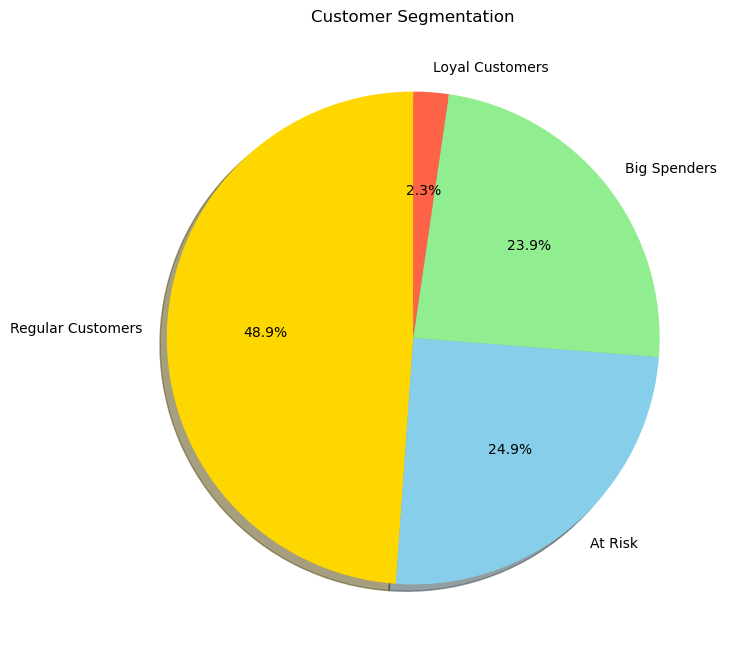

In [ ]:
#-------------------------------------------
# Customer segemntation
#-------------------------------------------
segment_counts = rfm['Segment'].value_counts()

colors = ['gold', 'skyblue','lightgreen','tomato']

plt.figure(figsize=(8,8))

plt.pie(
    segment_counts,
    labels = segment_counts.index,
    autopct = '%1.1f%%',
    colors= colors,
    shadow=True,
    startangle=90
)

plt.title("Customer Segmentation")
plt.show()

C:\Users\USHA RANI\AppData\Local\Temp\ipykernel_6712\3253334380.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


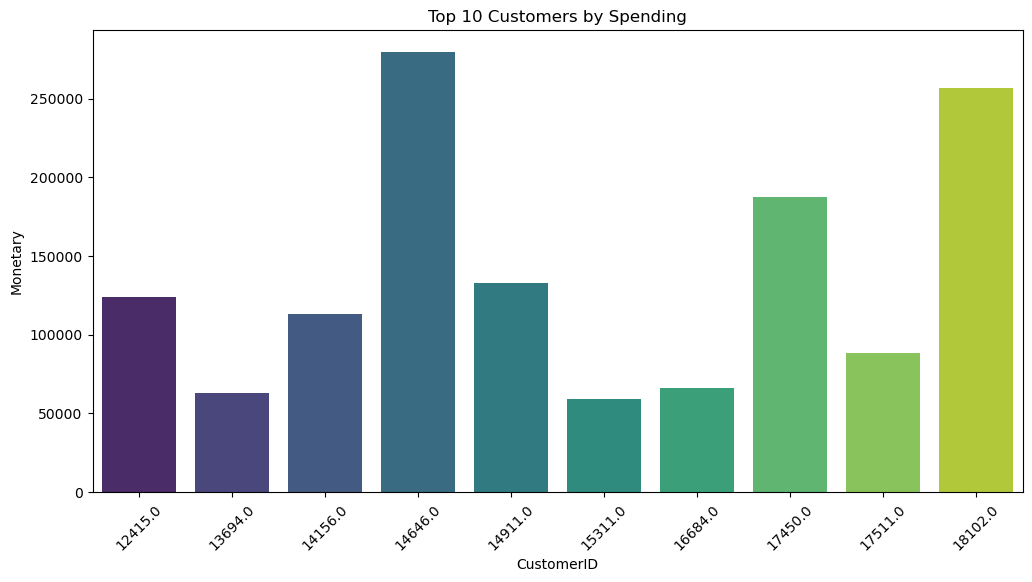

In [33]:
#--------------------------------------------
# Top Customers by Spending
#-------------------------------------------

top_customers = rfm.sort_values(
    by='Monetary',
    ascending= False
).head(10)

plt.figure(figsize=(12,6))

sns.barplot(
    x=top_customers.index,
    y=top_customers['Monetary'],
    palette= 'viridis'
)

plt.title("Top 10 Customers by Spending")

plt.xticks(rotation = 45)

plt.show()



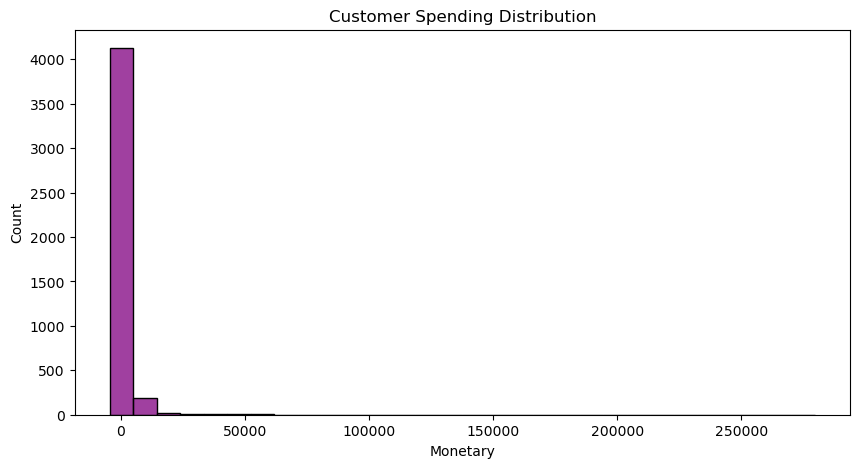

In [34]:
#-----------------------------------------------
#Spending Distribution Histogram
#-----------------------------------------------
plt.figure(figsize=(10,5))

sns.histplot(
    rfm['Monetary'],
    bins = 30,
    color ='purple'
)

plt.title("Customer Spending Distribution")

plt.show()

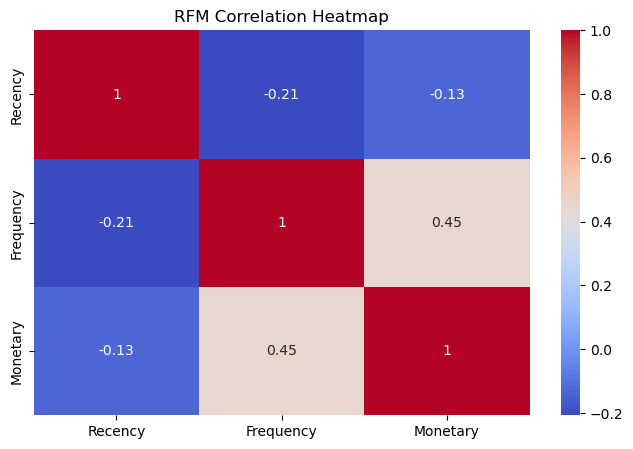

In [35]:
#-----------------------------------------
#RFM Correlation Heatmap
#-----------------------------------------

plt.figure(figsize=(8,5))

sns.heatmap(
    rfm[['Recency','Frequency','Monetary']].corr(),
    annot = True,
    cmap ='coolwarm'

)
plt.title("RFM Correlation Heatmap")
plt.show()

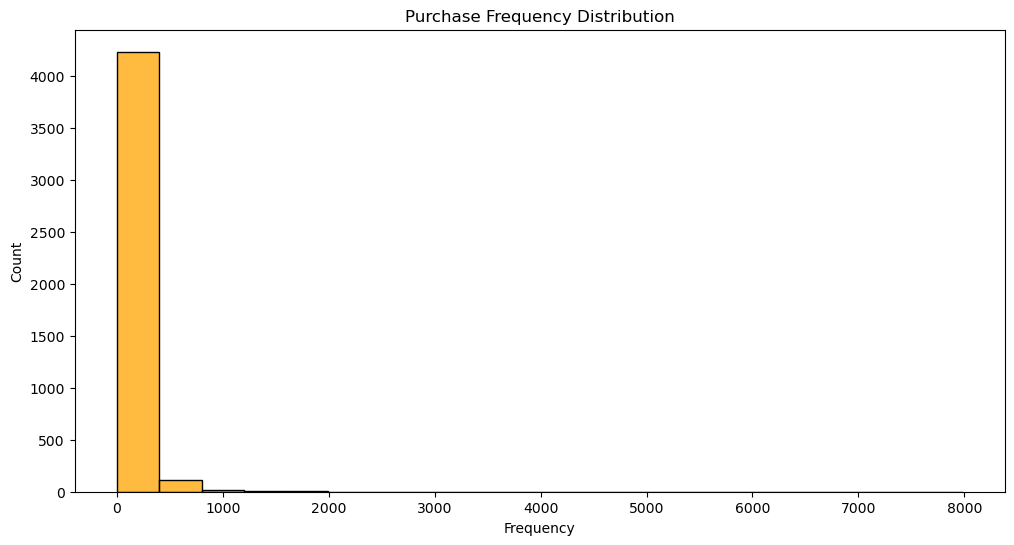

In [36]:
#-----------------------------------------
# Frequency Analysis
#----------------------------------------

plt.figure(figsize=(12,6))

sns.histplot(
    rfm['Frequency'],
    bins = 20,
    color = 'orange'
)
plt.title ("Purchase Frequency Distribution")

plt.show()


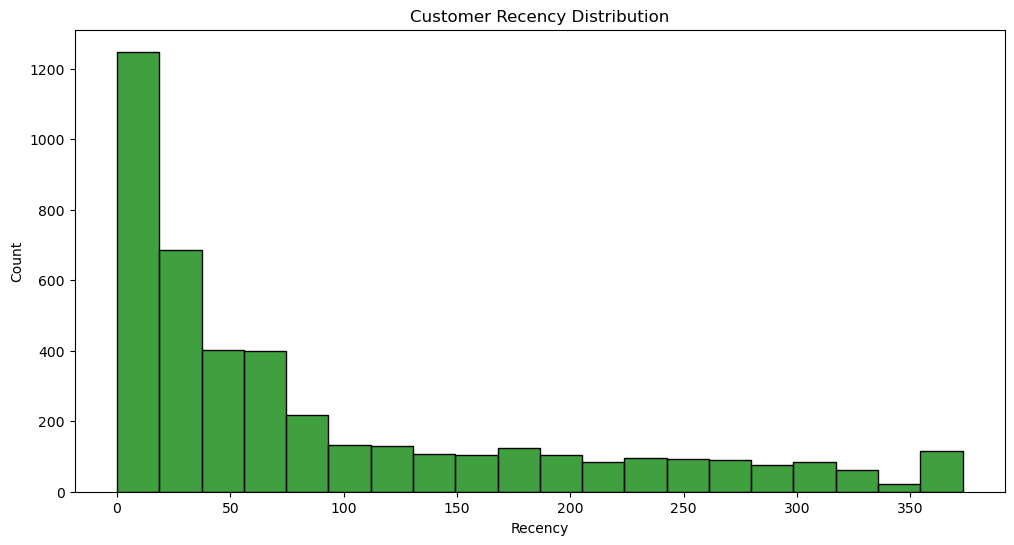

In [38]:
#---------------------------------
# Recency Distribution
#-----------------------------------

plt.figure(figsize=(12,6))

sns.histplot(
    rfm['Recency'],
    bins = 20,
    color ='green'
)

plt.title("Customer Recency Distribution")

plt.show()